# Decodificar os códigos do SINAN

**A pergunta:** a tabela veio cheia de `1`, `2` e `9`. O que cada número quer
dizer — e como transformar isso em algo que se possa ler?

**Fonte:** SINAN (notificações de agravos), pela biblioteca PySUS.

**Tempo estimado:** 2 a 4 minutos.

Os arquivos do DATASUS quase não têm texto. Sexo é `1` ou `2`, evolução é `1`,
`2`, `3` ou `9`, e o diagnóstico é um número de dois dígitos. Sem o dicionário,
a tabela é ilegível; com o dicionário errado, ela é pior — porque parece certa.

A boa notícia é que a PySUS **já traz o dicionário embarcado**: são 35 esquemas
com 1.963 colunas descritas, das quais **1.105 explicam os códigos, em
português**. A má notícia é que a função que deveria entregá-los não entrega.
Este notebook mostra o caminho que funciona, e mede o quanto dele dá para
confiar.

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import re
import pandas as pd
import yaml
import pysus

print("PySUS", pysus.__version__)

PySUS 2.10.6


In [4]:
# ---- O que você pode trocar -------------------------------------------
AGRAVO = "MENI"       # sigla de quatro letras (MENI = meningite)
ESQUEMA = "meningite"  # nome do arquivo de esquema correspondente
ANO = 2024

## 1. Onde está o dicionário

Os esquemas viajam **dentro do pacote** da PySUS, então não há download nem
internet envolvidos. A forma correta de alcançá-los é `importlib.resources`,
que funciona igual no seu computador e no Colab.

In [5]:
from importlib.resources import files

pasta = files("pysus.api.metadata.schemas")
inventario = []
for base in ["sia", "sih", "sim", "sinasc", "sinan"]:
    try:
        for arq in (pasta / base).iterdir():
            if not str(arq).endswith(".yaml"):
                continue
            dados = yaml.safe_load(arq.read_text(encoding="utf-8"))
            for chave, colunas in dados.items():
                com_codigo = sum(1 for c in colunas if c.get("categories"))
                inventario.append({"base": base, "esquema": chave,
                                   "colunas": len(colunas),
                                   "com código explicado": com_codigo})
    except Exception:
        pass

resumo = pd.DataFrame(inventario)
por_base = resumo.groupby("base")[["colunas", "com código explicado"]].sum()
por_base["esquemas"] = resumo.groupby("base").size()
print(f"{len(resumo)} esquemas, {resumo['colunas'].sum()} colunas, "
      f"{resumo['com código explicado'].sum()} com os códigos explicados\n")
por_base[["esquemas", "colunas", "com código explicado"]]

35 esquemas, 1963 colunas, 1105 com os códigos explicados


,esquemas,colunas,com código explicado
base,,,
sia,2,42,0
sih,3,130,0
sim,1,57,0
sinan,28,1694,1105
sinasc,1,40,0


Repare na coluna da direita: **os códigos explicados estão todos no SINAN**.
SIA, SIH, SIM e SINASC têm esquema — nomes e descrições de coluna — mas nenhuma
tabela de código. Para essas bases, este notebook ajuda a *entender* as colunas,
não a traduzir os valores.

## 2. A função oficial não entrega isso

A PySUS tem uma função para ler metadados de coluna. Ela existe, roda e devolve
resultado — só que o resultado ignora o agravo que você pediu.

In [6]:
a = pysus.load_column_metadata("sinan", "Dengue")
b = pysus.load_column_metadata("sinan", "Tuberculose")
c = pysus.load_column_metadata("sinan", "AGRAVO_QUE_NAO_EXISTE")

print(f"Dengue:              {len(a)} colunas")
print(f"Tuberculose:         {len(b)} colunas")
print(f"Agravo inexistente:  {len(c)} colunas")
print(f"\nOs três devolvem o mesmo? {a.keys() == b.keys() == c.keys()}")

com_categoria = sum(1 for v in a.values() if isinstance(v, dict) and v.get("categories"))
print(f"Quantas trazem a explicação dos códigos? {com_categoria}")

Dengue:              1238 colunas
Tuberculose:         1238 colunas
Agravo inexistente:  1238 colunas
Os três devolvem o mesmo? True
Quantas trazem a explicação dos códigos? 0


Três respostas iguais para três perguntas diferentes, e nenhuma com os códigos.
Não é erro seu: o segundo argumento é ignorado, e as categorias ficam pelo
caminho. Por isso lemos o arquivo direto.

## 3. Lendo o esquema do agravo escolhido

In [7]:
esquema_bruto = yaml.safe_load(
    (pasta / "sinan" / f"{ESQUEMA}.yaml").read_text(encoding="utf-8")
)
colunas = list(esquema_bruto.values())[0]

print(f"{ESQUEMA}: {len(colunas)} colunas descritas, "
      f"{sum(1 for c in colunas if c.get('categories'))} com códigos\n")

for c in colunas:
    if c["name"] in ("EVOLUCAO", "CLASSI_FIN", "CON_DIAGES"):
        print(f"{c['name']}")
        print(f"   o que é:  {str(c.get('description_pt', ''))[:70]}")
        print(f"   códigos:  {str(c.get('categories', ''))[:110]}")

meningite: 100 colunas descritas, 60 com códigos
CLASSI_FIN
   o que é:  Informa se o diagnóstico final está confirmando ou descartado
   códigos:  1-confirmado 2-descartado
CON_DIAGES
   o que é:  
   códigos:  1-Meningococcemia 2-Meningite Meningocócic a 3-Meningite Meningocócica com Meningococcemia 4-Meningite Tubercu
EVOLUCAO
   o que é:  evolução do caso
   códigos:  1-alta 2-óbito por meningite 3-óbito por outra causa 9-ignorado


## 4. Transformar o texto do dicionário em tabela

Os códigos vêm numa **frase**, não numa tabela: `"1-alta 2-óbito por meningite
3-óbito por outra causa 9-ignorado"`. É preciso quebrá-la — e é aqui que dá para
errar feio, porque alguns rótulos contêm números e hifens dentro deles
(`"1- 0 - 1h 2- 1 - 3h"` é uma faixa de horas, não os códigos 0 e 1).

A regra que usamos: **só aceitamos códigos em ordem crescente**. Um número que
apareça fora de ordem é parte do rótulo, não um código novo. E, depois de
quebrar, conferimos se algum rótulo ainda parece ter engolido outro — quando
parece, marcamos o campo como **não confiável** em vez de rotular errado.

In [8]:
CODIGO = re.compile(r"(?:(?<=^)|(?<=\s))(\d{1,2})\s*[–\-.:]\s*")
SUJO = re.compile(r"\d{1,2}\s*[–\-.]\s*\S")


def ler_codigos(texto: str) -> dict:
    """Devolve {codigo: rotulo}. Vazio quando o texto nao e lista de codigos."""
    marcas, anterior, validas = list(CODIGO.finditer(texto)), -1, []
    for m in marcas:
        numero = int(m.group(1))
        if numero > anterior:          # so aceita codigo em ordem crescente
            validas.append(m)
            anterior = numero
    tabela = {}
    for i, m in enumerate(validas):
        fim = validas[i + 1].start() if i + 1 < len(validas) else len(texto)
        rotulo = texto[m.end():fim].strip(" .;,")
        if rotulo:
            tabela[m.group(1)] = rotulo
    return tabela


def confiavel(tabela: dict) -> bool:
    """Rotulo que ainda contem 'numero-' provavelmente engoliu outra entrada."""
    return bool(tabela) and not any(SUJO.search(r) for r in tabela.values())


print("Exemplo:", ler_codigos("1-alta 2-óbito por meningite 3-óbito por outra causa 9-ignorado"))
print()
armadilha = "1- 0 - 1h 2- 1 - 3h 3- 3 - 6h 4- 6 - 12h 5- 12 e 24h"
print("O caso difícil:", armadilha)
print("   lido como:", ler_codigos(armadilha))
print("   confiável?", confiavel(ler_codigos(armadilha)), "— e por isso não seria usado")

Exemplo: {'1': 'alta', '2': 'óbito por meningite', '3': 'óbito por outra causa', '9': 'ignorado'}
O caso difícil: 1- 0 - 1h 2- 1 - 3h 3- 3 - 6h 4- 6 - 12h 5- 12 e 24h
   lido como: {'1': '0 - 1h', '2': '1 - 3h', '3': '3 - 6h', '6': '12h 5- 12 e 24h'}
   confiável? False — e por isso não seria usado


In [9]:
dicionario, descartados = {}, []
for c in colunas:
    if not c.get("categories"):
        continue
    tabela = ler_codigos(str(c["categories"]))
    if confiavel(tabela):
        dicionario[c["name"]] = tabela
    else:
        descartados.append(c["name"])

total_com_codigo = sum(1 for c in colunas if c.get("categories"))
print(f"Campos com códigos no esquema:     {total_com_codigo}")
print(f"Lidos com segurança:               {len(dicionario)}")
print(f"Descartados por não dar confiança: {len(descartados)} {descartados}")

Campos com códigos no esquema:     60
Lidos com segurança:               34
Descartados por não dar confiança: 26 ['DT_INVEST', 'ATE_MUNICI', 'ATE_HOSP_1', 'LAB_CTLESA', 'LAB_CTSANG', 'LAB_CTESCA', 'LAB_BCLIQU', 'LAB_BCLESA', 'LAB_BCSANG', 'LAB_BCESCA', 'LAB_CILIQU', 'LAB_CISANG', 'LAB_AGLIQU', 'LAB_AGSANG', 'LAB_ISLIQU', 'LAB_ISFEZE', 'LAB_PCLIQU', 'LAB_PCLESA', 'LAB_PCSANG', 'LAB_PCESCA', 'CLA_ME_BAC', 'CLA_ME_ASS', 'CLA_ME_ETI', 'CRITERIO', 'CLA_SOROGR', 'NU_LOTE_I']


## 5. Os dados de verdade

Uma armadilha antes: a função aceita a **sigla de quatro letras**, não o nome do
agravo. Pedir pelo nome devolve zero arquivos, sem erro nenhum — e você conclui
que não há dados.

In [10]:
from pysus import sinan

por_sigla = sinan(disease=AGRAVO, year=ANO, as_dataframe=False)
por_nome = sinan(disease="Meningite", year=ANO, as_dataframe=False)

print(f"sinan(disease={AGRAVO!r}) devolveu {len(por_sigla)} arquivo(s)")
print(f"sinan(disease='Meningite') devolveu {len(por_nome)} arquivo(s)  <- mesma base!")
print("\nUse sempre a sigla. As siglas estão no notebook 02-descobrir-dados-disponiveis.")

caminho = str(por_sigla[0])
tabela = pd.read_parquet(caminho)
print(f"\n{len(tabela):,} notificações, {len(tabela.columns)} colunas")

sinan(disease='MENI') devolveu 1 arquivo(s)
sinan(disease='Meningite') devolveu 0 arquivo(s)  <- mesma base!
Use sempre a sigla. As siglas estão no notebook 02-descobrir-dados-disponiveis.
25,487 notificações, 131 colunas


## 6. Aplicar os rótulos

Só rotulamos as colunas que existem **no arquivo** e cujo dicionário passou na
conferência. E guardamos a coluna original ao lado: rotular é para ler, não para
substituir o dado.

In [11]:
aplicaveis = [c for c in dicionario if c in tabela.columns]
print(f"Colunas que dá para rotular neste arquivo: {len(aplicaveis)} "
      f"de {len(dicionario)} do dicionário")


# Casa o valor com o codigo, tolerando zero a esquerda: o arquivo grava 05 e o
# esquema diz 5, sao o mesmo codigo. Tentamos primeiro o valor como veio e, so
# para o que sobrou, a versao sem o zero — nunca o contrario, para nao criar
# casamento onde nao havia.
def mapear(valores, tabela_de_codigos):
    limpo = valores.astype(str).str.strip()
    rotulo = limpo.map(tabela_de_codigos)
    faltando = rotulo.isna() & limpo.str.fullmatch(r"0[0-9]+")
    if faltando.any():
        rotulo[faltando] = limpo[faltando].str.lstrip("0").map(tabela_de_codigos)
    return rotulo


legivel = tabela.copy()
for coluna in aplicaveis:
    legivel[coluna + "_rotulo"] = mapear(legivel[coluna], dicionario[coluna])

mostrar = ["CLASSI_FIN", "EVOLUCAO", "CON_DIAGES"]
mostrar = [c for c in mostrar if c + "_rotulo" in legivel.columns]
legivel[[x for c in mostrar for x in (c, c + "_rotulo")]].head(8)

Colunas que dá para rotular neste arquivo: 34 de 34 do dicionário


,CLASSI_FIN,CLASSI_FIN_rotulo,EVOLUCAO,EVOLUCAO_rotulo,CON_DIAGES,CON_DIAGES_rotulo
0,1,confirmado,9,ignorado,05,Meningite por outras bactérias
1,2,descartado,,NaN,00,NaN
2,2,descartado,,NaN,00,NaN
3,1,confirmado,1,alta,02,Meningite Meningocócic a
4,1,confirmado,1,alta,10,Meningite por Pneumococo
5,1,confirmado,1,alta,10,Meningite por Pneumococo
6,2,descartado,,NaN,00,NaN
7,2,descartado,,NaN,00,NaN


## 7. O que ficou sem rótulo — a parte que não se pode pular

Um dicionário incompleto não avisa: ele simplesmente deixa vazio. Se você
contar só o que foi rotulado, some casos sem perceber. Então medimos.

In [12]:
faltas = []
for coluna in aplicaveis:
    original = legivel[coluna].astype(str).str.strip()
    preenchidos = original[(original != "") & (original != "None")]
    if not len(preenchidos):
        continue
    sem = legivel.loc[preenchidos.index, coluna + "_rotulo"].isna()
    if sem.any():
        codigos = preenchidos[sem.values]
        faltas.append({
            "coluna": coluna,
            "sem rótulo": int(sem.sum()),
            "% da coluna": round(sem.mean() * 100, 1),
            "códigos": ", ".join(sorted(codigos.unique())[:6]),
        })

quadro = pd.DataFrame(faltas).sort_values("% da coluna", ascending=False)
if len(quadro):
    # Quando a MAIORIA da coluna nao tem rotulo, o suspeito e o dicionario, nao
    # o dado: um campo real nao e preenchido com codigo invalido em 8 de cada
    # 10 registros.
    quadro["veredito"] = [
        "conflito — confira a fonte oficial" if p > 50 else "lacuna pontual"
        for p in quadro["% da coluna"]
    ]
    print(f"{len(quadro)} colunas têm código que o dicionário não explica:")
    print()
    display(quadro.set_index("coluna"))
    suspeitas = quadro[quadro["veredito"].str.startswith("conflito")]
    if len(suspeitas):
        print()
        print("Leia a linha de cima com atenção. Em "
              f"{', '.join(suspeitas['coluna'])} o dicionário deixa de fora o")
        print("valor MAIS COMUM do arquivo. Isso não quer dizer que o dado")
        print("esteja errado, nem que a PySUS tenha errado: quer dizer que o")
        print("dicionário e o arquivo discordam, e que só a fonte oficial")
        print("resolve. NÃO rotule antes de conferir — a célula seguinte mostra")
        print("como esse caso foi resolvido.")
    print()
    print("As demais são lacunas: códigos que o esquema simplesmente não lista.")
    print("Decida o que fazer com eles e diga ao leitor quantos foram.")
else:
    print("Nenhum código ficou sem rótulo neste arquivo.")

3 colunas têm código que o dicionário não explica:


,sem rótulo,% da coluna,códigos,veredito
coluna,,,,
ANT_TRAUMA,21308,89.9,2,conflito — confira a fonte oficial
CON_DIAGES,496,3.4,"%, 00",lacuna pontual
CLASSI_FIN,402,1.6,8,lacuna pontual


Leia a linha de cima com atenção. Em ANT_TRAUMA o dicionário deixa de fora o
valor MAIS COMUM do arquivo. Isso não quer dizer que o dado
esteja errado, nem que a PySUS tenha errado: quer dizer que o
dicionário e o arquivo discordam, e que só a fonte oficial
resolve. NÃO rotule antes de conferir — a célula seguinte mostra
como esse caso foi resolvido.
As demais são lacunas: códigos que o esquema simplesmente não lista.
Decida o que fazer com eles e diga ao leitor quantos foram.


### O que aconteceu quando fomos conferir

Vale contar o caso inteiro, porque ele é mais interessante do que "o dicionário
está errado".

`ANT_TRAUMA` registra se o paciente tinha **traumatismo prévio**, um fator de
risco para meningite bacteriana. O arquivo traz `2` em 84% das linhas e **nenhum
`3`**. Fomos aos documentos do Ministério da Saúde, e encontramos os dois
discordando entre si:

| Fonte oficial | Traumatismo |
|---|---|
| **Ficha de Investigação – Meningite** (SVS, 15/10/2007), campo 34 | `1 - Sim` · `2 - Não` · `9 - Ignorado` |
| **Dicionário de Dados SINAN NET v5** (revisado em julho/2010), p. 4 | `1. Sim` · **`3. Não`** · `9.Ignorado` |

No dicionário, o Traumatismo é o **único** campo do bloco 34 que pula o código 2
— os vizinhos (`ANT_IMUNO`, `ANT_IRA`, `ANT_TUBE`, `ANT_INF_HO`, `ANT_OUTRO`)
todos usam `2. Não`. Na ficha, uma legenda única vale para o bloco inteiro, e ela
diz `2 - Não`.

E a PySUS? Não errou nada. O cabeçalho do próprio arquivo de esquema diz de onde
ele veio:

```
# Column schemas for SINAN - MENI
# Source: MENI.csv from SINAN metadata tarball
```

Ela reproduziu fielmente o dicionário oficial — inclusive a inconsistência dele.

**A conclusão, então, não é "o dicionário está errado".** É:

> Há conflito entre duas fontes oficiais. O instrumento com que o dado foi
> **coletado** diz `2 = Não`, e é o que o arquivo usa. O dicionário técnico diz
> `3 = Não`, e o código 3 não aparece nenhuma vez.

Com essa triangulação — ficha, dado observado e dicionário — recodificar `2` como
"Não" passa a ser defensável. O que não é defensável é fazer isso **sem dizer**.
Se você recodificar, registre a divergência no método, como fizemos aqui.

Repare no que a máquina fez e no que não fez: ela detectou a discordância e
parou. Quem resolveu foi a leitura dos documentos. É essa a divisão de trabalho
que a tabela acima propõe.

## 8. Agora a tabela responde a uma pergunta

Com os rótulos, uma pergunta clínica fica a uma linha de distância: **de que
tipo de meningite as pessoas morrem?**

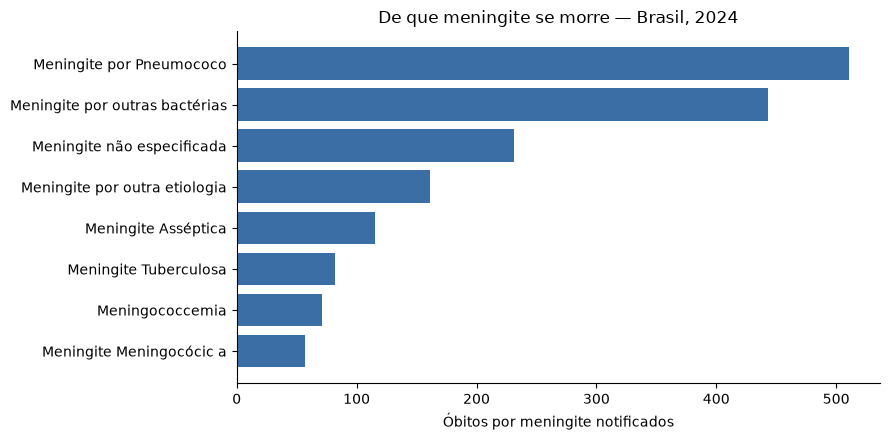

1,769 óbitos por meningite entre 25,487 notificações (6.9%).


In [13]:
import matplotlib.pyplot as plt

if "EVOLUCAO_rotulo" in legivel.columns and "CON_DIAGES_rotulo" in legivel.columns:
    obitos = legivel[legivel["EVOLUCAO_rotulo"].astype(str).str.contains(
        "óbito por meningite", case=False, na=False)]
    por_tipo = (obitos["CON_DIAGES_rotulo"].value_counts().head(8)
                .sort_values())

    figura, eixo = plt.subplots(figsize=(9, 4.5))
    eixo.barh([t[:42] for t in por_tipo.index], por_tipo.values, color="#3b6ea5")
    eixo.set_xlabel("Óbitos por meningite notificados")
    eixo.set_title(f"De que meningite se morre — Brasil, {ANO}", fontsize=12)
    eixo.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    print(f"{len(obitos):,} óbitos por meningite entre "
          f"{len(legivel):,} notificações "
          f"({len(obitos) / len(legivel) * 100:.1f}%).")
else:
    print("As colunas de evolução e diagnóstico não estão neste arquivo.")

## 9. Mandar para quem não usa Python

A PySUS grava Excel com uma aba de **procedência** junto. Vale o hábito: daqui
a três meses, a planilha ainda vai saber de onde veio.

In [14]:
import datetime
from pathlib import Path

recorte = legivel[[x for c in mostrar for x in (c, c + "_rotulo")]].head(500)
destino = Path("meningite-rotulada.xlsx")

baixado = datetime.datetime.fromtimestamp(
    Path(caminho).stat().st_mtime).strftime("%d/%m/%Y")

pysus.to_excel(recorte, destino, metadata={
    "fonte": f"SINAN/{AGRAVO}, {ANO}, DATASUS",
    "arquivo de origem": Path(caminho).name,
    "obtido em": baixado,
    "biblioteca": f"PySUS {pysus.__version__}",
    "dicionário": f"esquema {ESQUEMA}.yaml embarcado na PySUS",
    "aviso": "rótulos conferidos; ver colunas com código não explicado",
})
print(f"Gravado: {destino} ({destino.stat().st_size / 1024:.0f} KB)")
print("Abas: Data (os dados) e Metadata (de onde vieram).")

Gravado: meningite-rotulada.xlsx (17 KB)
Abas: Data (os dados) e Metadata (de onde vieram).


## Verificação de sanidade

Rotular é justamente o passo em que um erro silencioso vira relatório errado.
As conferências abaixo falham alto se alguma premissa deixar de valer.

In [15]:
print("Verificações\n")
falhas = []

ok1 = len(dicionario) > 20
print(f"1. O esquema rendeu dicionário: {len(dicionario)} colunas — "
      f"{'confere' if ok1 else 'ATENÇÃO: quase nada foi lido'}")
falhas += [] if ok1 else ["dicionario"]

ok2 = len(aplicaveis) > 10
print(f"2. Colunas rotuladas no arquivo: {len(aplicaveis)} — "
      f"{'confere' if ok2 else 'ATENÇÃO: o esquema não casa com o arquivo'}")
falhas += [] if ok2 else ["casamento"]

# um rotulo conhecido tem de bater
esperado = dicionario.get("EVOLUCAO", {}).get("1", "")
ok3 = "alta" in esperado.lower()
print(f"3. EVOLUCAO código 1 = {esperado!r} — "
      f"{'confere' if ok3 else 'ATENÇÃO: o dicionário mudou'}")
falhas += [] if ok3 else ["rotulo"]

# rotular nao pode inventar nem perder linha
ok4 = len(legivel) == len(tabela)
print(f"4. Rotular não mudou o número de linhas: "
      f"{len(tabela):,} -> {len(legivel):,} "
      f"{'confere' if ok4 else 'ATENÇÃO'}")
falhas += [] if ok4 else ["linhas"]

# o total rotulado + sem rotulo tem de fechar com o preenchido
col = "EVOLUCAO"
if col in aplicaveis:
    orig = legivel[col].astype(str).str.strip()
    cheio = orig[(orig != "") & (orig != "None")]
    rotulado = legivel[col + "_rotulo"].notna().sum()
    nao = len(cheio) - rotulado
    ok5 = rotulado + nao == len(cheio)
    print(f"5. {col}: {rotulado:,} rotulados + {nao:,} sem rótulo = "
          f"{len(cheio):,} preenchidos {'confere' if ok5 else 'ATENÇÃO'}")
    falhas += [] if ok5 else ["soma"]

print()
print("ATENÇÃO: revise antes de usar." if falhas else
      "Tudo confere. Os rótulos vêm do esquema da PySUS 2.10.6, e o que ele não "
      "explica está medido acima.")

Verificações
1. O esquema rendeu dicionário: 34 colunas — confere
2. Colunas rotuladas no arquivo: 34 — confere
3. EVOLUCAO código 1 = 'alta' — confere
4. Rotular não mudou o número de linhas: 25,487 -> 25,487 confere
5. EVOLUCAO: 23,129 rotulados + 0 sem rótulo = 23,129 preenchidos confere
Tudo confere. Os rótulos vêm do esquema da PySUS 2.10.6, e o que ele não explica está medido acima.


## Como adaptar

- **Outro agravo:** troque `AGRAVO` (a sigla de quatro letras) e `ESQUEMA` (o
  nome do arquivo). Há 28 esquemas de SINAN: `chikungunya`, `dengue`, `chagas`,
  `hanseniase`, `hepatites`, `leptospirose`, `malaria`, `meningite`,
  `sifilis_congenita`, `tuberculose`, entre outros. A célula do inventário lista
  todos.
- **Outro ano:** troque `ANO`. Confira antes com
  `pysus.list_files(dataset="sinan", group=AGRAVO)`.
- **Outras bases:** SIA, SIH, SIM e SINASC têm esquema com a **descrição** das
  colunas, mas não com os códigos. Para elas, use o esquema para entender o que
  é cada coluna e monte a tradução dos valores a partir do DATASUS.
- **Antes de confiar no rótulo:** olhe sempre a tabela do passo 7. Um
  dicionário incompleto some com casos em silêncio, e o número que sobra tem
  cara de certo.

---

*Exemplo do PySusNoCode — [kraemeracademy.net](https://kraemeracademy.net).
Dados públicos do DATASUS via PySUS.*